In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [2]:
df = pd.read_csv("/content/paddydataset.csv")

TARGET = 'Paddy yield(in Kg)'
X = df.drop(columns=[TARGET]).copy()
y = df[TARGET].values.astype(float)

cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

In [4]:
# 80/20 train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=123
)

In [5]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols)
])

ols_pipe = Pipeline([
    ('prep',  preprocessor),
    ('model', LinearRegression())
])

ols_pipe.fit(X_train, y_train)

y_pred_train = ols_pipe.predict(X_train)
y_pred_test  = ols_pipe.predict(X_test)

In [7]:
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test  = np.sqrt(mean_squared_error(y_test,  y_pred_test))
mae_train  = mean_absolute_error(y_train, y_pred_train)
mae_test   = mean_absolute_error(y_test,  y_pred_test)
r2_train   = r2_score(y_train, y_pred_train)
r2_test    = r2_score(y_test,  y_pred_test)
mape_test  = np.mean(np.abs((y_test - y_pred_test) / y_test)) * 100

metrics = pd.DataFrame({
    'Metric':  ['RMSE (kg)', 'MAE (kg)', 'R^2', 'MAPE (%)'],
    'Train':   [f"{rmse_train:,.0f}", f"{mae_train:,.0f}", f"{r2_train:.4f}", '—'],
    'Test':    [f"{rmse_test:,.0f}",  f"{mae_test:,.0f}",  f"{r2_test:.4f}",  f"{mape_test:.2f}%"]
})
print(metrics.to_string(index=False))

   Metric  Train   Test
RMSE (kg)    928    949
 MAE (kg)    706    718
      R^2 0.9899 0.9890
 MAPE (%)      —  3.72%


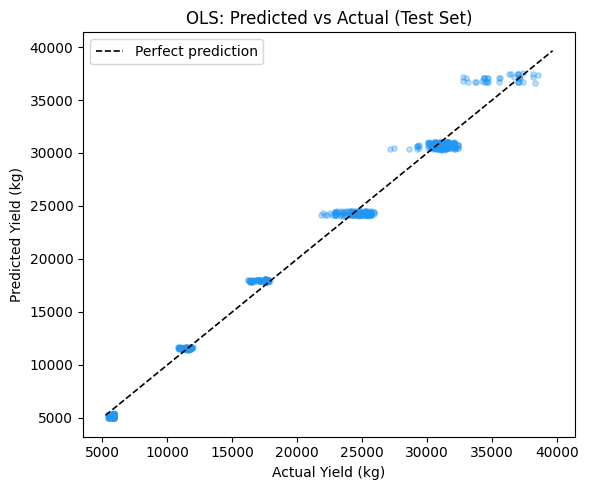

In [8]:
# predicted vs actual plot
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_test, y_pred_test, alpha=0.3, s=15, color='#2196F3')
lo, hi = y_test.min() * 0.97, y_test.max() * 1.03
ax.plot([lo, hi], [lo, hi], 'k--', lw=1.2, label='Perfect prediction')
ax.set_xlabel('Actual Yield (kg)')
ax.set_ylabel('Predicted Yield (kg)')
ax.set_title('OLS: Predicted vs Actual (Test Set)')
ax.legend()
plt.tight_layout()
plt.show()

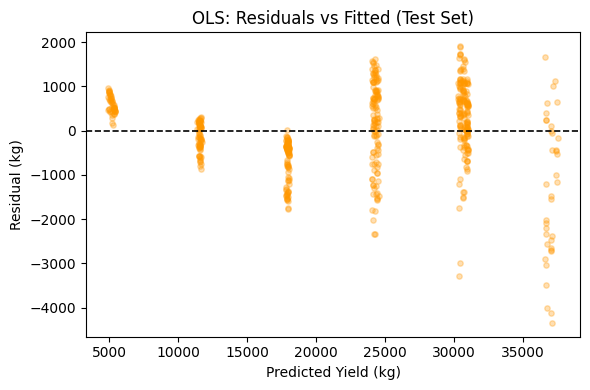

In [9]:
# residual plot
residuals = y_test - y_pred_test

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(y_pred_test, residuals, alpha=0.3, s=15, color='#FF9800')
ax.axhline(0, color='k', lw=1.2, linestyle='--')
ax.set_xlabel('Predicted Yield (kg)')
ax.set_ylabel('Residual (kg)')
ax.set_title('OLS: Residuals vs Fitted (Test Set)')
plt.tight_layout()
plt.show()

In [10]:
# 5 fold cv on the training set to assess variance in model performance
cv_scores = cross_val_score(
    ols_pipe, X_train, y_train,
    cv=5, scoring='neg_root_mean_squared_error'
)
cv_rmse = -cv_scores

print(f"CV RMSE across folds: {cv_rmse}")
print(f"Mean CV RMSE:  {cv_rmse.mean():,.0f} kg")
print(f"Std CV RMSE:   {cv_rmse.std():,.0f} kg")
print(f"\nTrain RMSE:    {rmse_train:,.0f} kg")
print(f"Test RMSE:     {rmse_test:,.0f} kg")
print(f"Overfit gap:   {rmse_test - rmse_train:+,.0f} kg")

CV RMSE across folds: [ 911.23242454  887.20370646  901.64646946  933.57690975 1030.17403197]
Mean CV RMSE:  933 kg
Std CV RMSE:   51 kg

Train RMSE:    928 kg
Test RMSE:     949 kg
Overfit gap:   +21 kg


The model shows very low bias, achieving an R² of 0.989 on the test set, meaning it explains roughly 99% of the variation in paddy yield. The overfit gap between train and test RMSE is small, and the standard deviation across cross-validation folds is narrow, indicating low variance as well. This suggests OLS is a well-fitted model for this dataset: it generalizes reliably without needing additional complexity or regularization.

OLS linear regression is the appropriate baseline model for this task. The target variable, paddy yield in kilograms, is continuous, and the features include a structured mix of numerical agricultural inputs and categorical variables. OLS is interpretable, computationally efficient, and well-suited for establishing a performance benchmark before introducing regularization. The strong R² and low RMSE on the held-out test set confirm that a linear relationship adequately captures the variation in yield across farm plots. Regularized variants such as Ridge and Lasso are explored in the following section to assess whether any additional generalization benefit can be achieved.